In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import json
import os
import imageio.v2 as imageio
from PIL import Image
import io

from src.geospatial import load_all_assets, _get_year_aware_reverse, _is_active, _get_opacity

civs_df, mapping, colour_map, available_years, stressors_df = load_all_assets()

BASEMAP_DIR = "../data/geospatial/historical-basemaps/geojson"
GIF_DIR     = "../data/geospatial/gifs"
os.makedirs(GIF_DIR, exist_ok=True)

print(f"Civilisations: {len(civs_df)}")
print(f"Snapshots: {len(available_years)}")
print(f"GIF output dir: {GIF_DIR}")

Civilisations: 112
Snapshots: 48
GIF output dir: ../data/geospatial/gifs


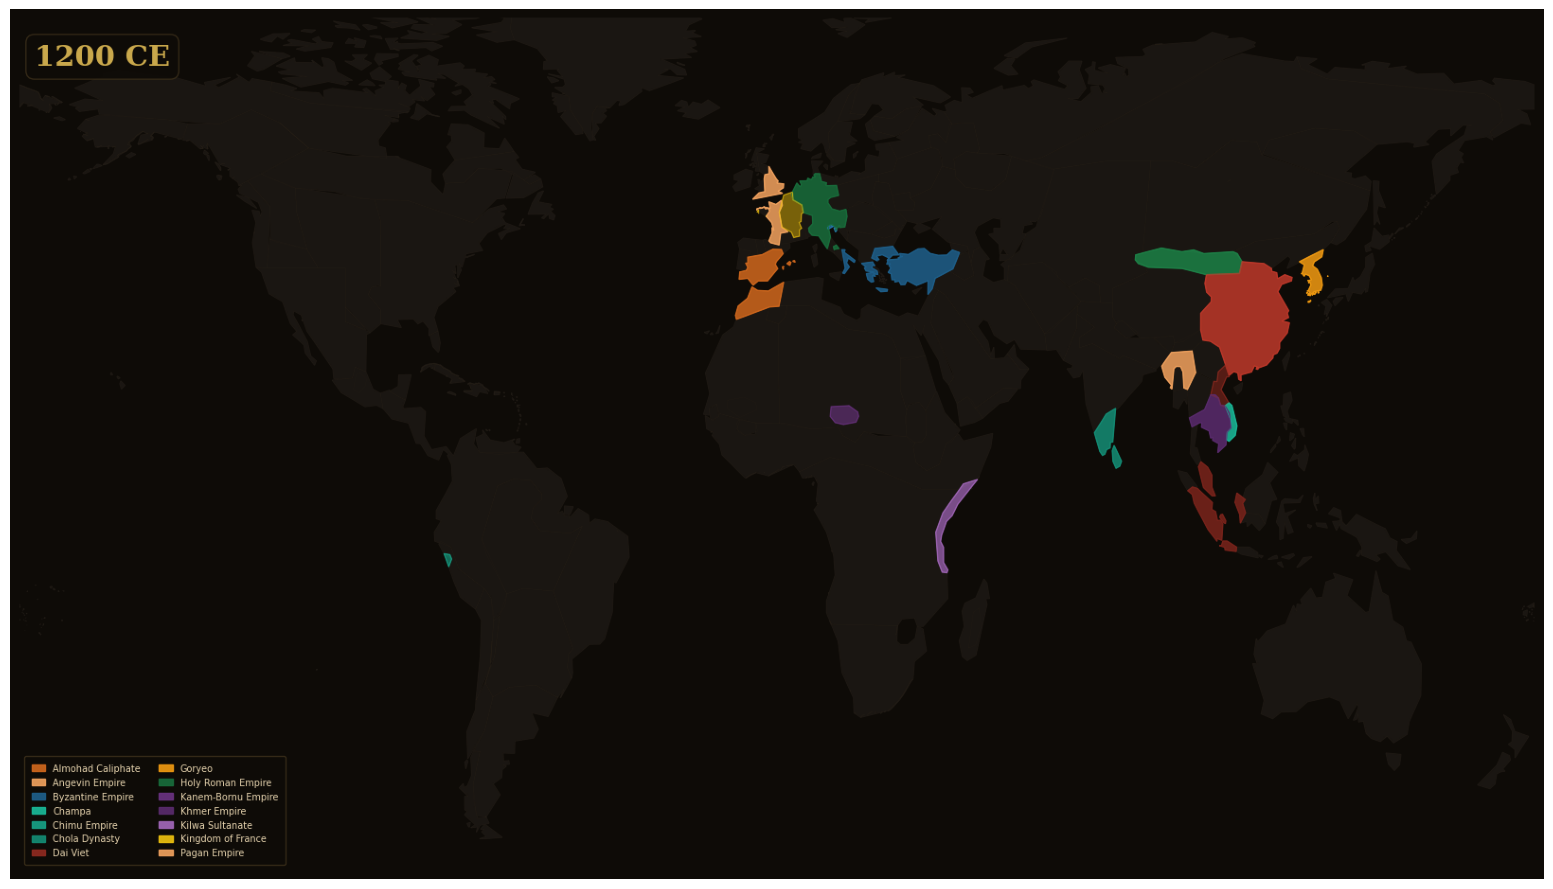

Test frame size: (1620, 919)


In [5]:
def render_frame(year, civs_df, mapping, colour_map, stressors_df=None,
                 figsize=(16, 9), dpi=100):
    """Render one map frame. Returns PIL Image."""
    from src.geospatial import year_to_filename, _polygon_segments

    year_reverse = _get_year_aware_reverse(mapping, year)

    fpath = os.path.join(BASEMAP_DIR, year_to_filename(year))
    if not os.path.exists(fpath):
        return None

    gdf        = gpd.read_file(fpath)
    empire_gdf = gdf[gdf['NAME'].isin(year_reverse.keys())].copy()
    world_gdf  = gdf[~gdf['NAME'].isin(year_reverse.keys())].copy()

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, facecolor='#0e0b07')
    ax.set_facecolor('#0a0e14')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 80)
    ax.axis('off')

    # Base world
    for _, row in world_gdf.iterrows():
        try:
            geom = row.geometry
            if geom is None or geom.is_empty:
                continue
            geom = geom.simplify(0.5, preserve_topology=True)
            polys = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
            for poly in polys:
                if poly.is_empty: continue
                xs, ys = poly.exterior.xy
                ax.fill(xs, ys, color='#1a1612', zorder=1)
                ax.plot(xs, ys, color='#2a2218', linewidth=0.15, zorder=2)
        except Exception:
            continue

    # Empire polygons
    legend_entries = {}
    for _, row in empire_gdf.iterrows():
        civ_name = year_reverse.get(row['NAME'])
        if not civ_name:
            continue
        civ_data = civs_df[civs_df['name'] == civ_name]
        if civ_data.empty:
            continue
        civ_row = civ_data.iloc[0]
        if not _is_active(civ_row, year):
            continue

        opacity = _get_opacity(civ_row, year)
        if opacity < 0.05:
            continue

        colour = colour_map.get(civ_name, '#888888')
        r, g, b = mcolors.to_rgb(colour)

        try:
            geom = row.geometry
            if geom is None or geom.is_empty:
                continue
            geom = geom.simplify(0.3, preserve_topology=True)
            polys = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
            for poly in polys:
                if poly.is_empty or len(poly.exterior.coords) < 3:
                    continue
                xs, ys = poly.exterior.xy
                if max(xs) - min(xs) > 180:
                    continue
                ax.fill(xs, ys, color=(r, g, b), alpha=opacity, zorder=3)
                ax.plot(xs, ys, color=colour, linewidth=0.4,
                        alpha=min(1.0, opacity + 0.2), zorder=4)
            legend_entries[civ_name] = colour
        except Exception:
            continue

    # Year label
    year_label = f"{abs(year)} BCE" if year < 0 else f"{year} CE"
    ax.text(0.01, 0.97, year_label,
            transform=ax.transAxes,
            fontsize=22, fontweight='bold', color='#c9a84c',
            va='top', fontfamily='serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0e0b07',
                      alpha=0.85, edgecolor='#3a2e1a'))

    # Active catastrophic stressors
    if stressors_df is not None:
        active_s = stressors_df[
            (stressors_df['start_year'] <= year) &
            (stressors_df['end_year']   >= year) &
            (stressors_df['severity'].isin(['catastrophic', 'severe']))
        ]
        if len(active_s) > 0:
            stressor_text = "  ·  ".join(active_s['event_name'].tolist()[:2])
            ax.text(0.99, 0.97, f"⚡ {stressor_text}",
                    transform=ax.transAxes,
                    fontsize=7, color='#E15759', va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#0e0b07',
                              alpha=0.85, edgecolor='#5a1a1a'))

    # Legend — show max 12 entries, larger font
    if legend_entries:
        # Sort by empire size for most prominent first
        sorted_entries = sorted(legend_entries.items())[:14]  # cap at 14
        patches = [
            mpatches.Patch(color=col, label=name, alpha=0.9)
            for name, col in sorted_entries
        ]
        ncol = 2
        ax.legend(handles=patches, loc='lower left', fontsize=7,
                  ncol=ncol, framealpha=0.92,
                  facecolor='#0e0b07', edgecolor='#3a2e1a',
                  labelcolor='#e8d5b0', markerscale=1.2,
                  handlelength=1.5, borderpad=0.8, labelspacing=0.5)

    plt.tight_layout(pad=0)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi,
                facecolor='#0e0b07', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).copy()


# Quick test — Medieval snapshot
test = render_frame(1200, civs_df, mapping, colour_map, stressors_df)
plt.figure(figsize=(16, 9))
plt.imshow(test)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Test frame size: {test.size}")

In [6]:
def generate_gif(era_name, era_key, years, civs_df, mapping, colour_map,
                 stressors_df, fps=1.5, dpi=100, figsize=(16, 9)):
    """
    Generate a GIF for a given era.
    fps controls speed — 1.5 = 1.5 frames per second (good for reading labels)
    """
    print(f"\nGenerating: {era_name}")
    print(f"  Snapshots: {len(years)} ({years[0]} to {years[-1]})")

    frames = []
    for i, year in enumerate(years):
        print(f"  Frame {i+1}/{len(years)}: {abs(year)} {'BCE' if year < 0 else 'CE'}",
              end='\r')
        frame = render_frame(year, civs_df, mapping, colour_map,
                             stressors_df, figsize=figsize, dpi=dpi)
        if frame is not None:
            frames.append(np.array(frame))

    if not frames:
        print(f"  No frames generated for {era_name}")
        return None

    out_path = os.path.join(GIF_DIR, f"collapse_{era_key}.gif")
    duration  = int(1000 / fps)  # ms per frame

    imageio.mimsave(
        out_path,
        frames,
        format='GIF',
        duration=duration,
        loop=0  # loop forever
    )

    size_mb = os.path.getsize(out_path) / 1024 / 1024
    print(f"\n  ✓ Saved: {out_path}")
    print(f"  Size: {size_mb:.1f} MB  |  Frames: {len(frames)}  |  FPS: {fps}")
    return out_path


# Era definitions
ERAS = [
    ("Ancient World (3000 BCE – 500 CE)",  "ancient",
     [y for y in available_years if -3000 <= y <= 500]),
    ("Medieval World (500 – 1500 CE)",     "medieval",
     [y for y in available_years if 500 < y <= 1500]),
    ("Early Modern (1500 – 1800 CE)",      "early_modern",
     [y for y in available_years if 1500 < y <= 1800]),
    ("Modern Era (1800 – 2010 CE)",        "modern",
     [y for y in available_years if 1800 < y <= 2010]),
]

print("Era snapshot counts:")
for name, key, years in ERAS:
    print(f"  {name}: {len(years)} snapshots")

Era snapshot counts:
  Ancient World (3000 BCE – 500 CE): 17 snapshots
  Medieval World (500 – 1500 CE): 12 snapshots
  Early Modern (1500 – 1800 CE): 7 snapshots
  Modern Era (1800 – 2010 CE): 12 snapshots


In [8]:
import imageio.v2 as imageio
import os

for era_name, era_key, era_years in ERAS:
    print(f"\nGenerating: {era_name}")
    
    frames = []
    for i, year in enumerate(era_years):
        print(f"  Frame {i+1}/{len(era_years)}: "
              f"{abs(year)} {'BCE' if year < 0 else 'CE'}", end='\r')
        frame = render_frame(year, civs_df, mapping, colour_map,
                             stressors_df, figsize=(16, 9), dpi=100)
        if frame is not None:
            frames.append(np.array(frame))

    if not frames:
        print(f"  No frames for {era_name}")
        continue

    # Save as MP4
    mp4_path = os.path.join(GIF_DIR, f"collapse_{era_key}.mp4")
    fps = 1.2  # slow enough to read each frame

    writer = imageio.get_writer(mp4_path, fps=fps, codec='libx264',
                                 quality=8, macro_block_size=1)
    for frame in frames:
        writer.append_data(frame)
    writer.close()

    size_mb = os.path.getsize(mp4_path) / 1024 / 1024
    print(f"\n  ✓ Saved: {mp4_path}")
    print(f"  Size: {size_mb:.1f} MB  |  Frames: {len(frames)}  |  FPS: {fps}")

print("\n✓ All MP4s generated")
for f in os.listdir(GIF_DIR):
    if f.endswith('.mp4'):
        size = os.path.getsize(os.path.join(GIF_DIR, f)) / 1024 / 1024
        print(f"  {f}: {size:.1f} MB")


Generating: Ancient World (3000 BCE – 500 CE)
  Frame 17/17: 500 CEE
  ✓ Saved: ../data/geospatial/gifs\collapse_ancient.mp4
  Size: 0.0 MB  |  Frames: 17  |  FPS: 1.2

Generating: Medieval World (500 – 1500 CE)
  Frame 12/12: 1500 CE
  ✓ Saved: ../data/geospatial/gifs\collapse_medieval.mp4
  Size: 0.0 MB  |  Frames: 12  |  FPS: 1.2

Generating: Early Modern (1500 – 1800 CE)
  Frame 7/7: 1800 CE
  ✓ Saved: ../data/geospatial/gifs\collapse_early_modern.mp4
  Size: 0.0 MB  |  Frames: 7  |  FPS: 1.2

Generating: Modern Era (1800 – 2010 CE)
  Frame 12/12: 2010 CE
  ✓ Saved: ../data/geospatial/gifs\collapse_modern.mp4
  Size: 0.0 MB  |  Frames: 12  |  FPS: 1.2

✓ All MP4s generated
  collapse_ancient.mp4: 0.0 MB
  collapse_early_modern.mp4: 0.0 MB
  collapse_medieval.mp4: 0.0 MB
  collapse_modern.mp4: 0.0 MB


In [9]:
import pandas as pd
df = pd.read_csv("../data/processed/civilisations_clean.csv")
print(f"Min founded: {df['founded_year'].min()}")
print(f"Max collapse: {df['collapse_end_year'].max()}")
print(f"Span: {df['collapse_end_year'].max() - df['founded_year'].min()}")

Min founded: -3000
Max collapse: 1999
Span: 4999


In [10]:
import subprocess
result = subprocess.run(
    ['pip', 'freeze'],
    capture_output=True, text=True
)
# Filter to only packages we actually use
keep = [
    'streamlit', 'pandas', 'numpy', 'plotly', 'folium',
    'streamlit-folium', 'geopandas', 'scikit-learn', 'shap',
    'networkx', 'scipy', 'matplotlib', 'imageio', 'Pillow',
    'fiona', 'pyproj', 'shapely'
]
lines = result.stdout.splitlines()
filtered = [l for l in lines if any(k.lower() in l.lower() for k in keep)]
for l in filtered:
    print(l)

folium @ file:///home/conda/feedstock_root/build_artifacts/folium_1750113804946/work
geopandas @ file:///home/conda/feedstock_root/build_artifacts/geopandas_1773131057865/work
ImageIO==2.37.3
imageio-ffmpeg==0.6.0
matplotlib @ file:///D:/bld/matplotlib-suite_1715976329482/work
matplotlib-inline==0.2.1
networkx @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_networkx_1765215107/work
numpy @ file:///D:/bld/bld/rattler-build_numpy_1773839131/work/dist/numpy-2.4.3-cp311-cp311-win_amd64.whl#sha256=ab655e7b39e4f9e1dc0410b9ee943cfd1b8285ef0776679e3c6096c89e5a2bba
pandas @ file:///D:/bld/bld/rattler-build_pandas_1774916643/work
pillow @ file:///C:/Users/task_177247533352805/croot/pillow_1772475427665/work
plotly==6.7.0
pyproj @ file:///D:/bld/bld/rattler-build_pyproj_1772623260/work
scikit-learn @ file:///D:/bld/bld/rattler-build_scikit-learn_1765801251/work/dist/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl#sha256=6b709d3d1e68d89c77b77f0fb7aa31e6f68e5148d615ecd56f94da3e12